# “What are the key factors driving customer churn, and how can the company reduce it?”

### GOAL => “Reduce Customer Churn by Identifying Its Main Causes and Providing Actionable Business Recommendations.”

### Import main libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### make folder for storing images

In [24]:
import os
folder_name = "visuals"
if not os.path.exists(folder_name):
    os.makedirs(folder_name)


### Read the Data from CSV through pandas

In [2]:
df = pd.read_csv("IT_customer_churn.csv")
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### check null value

In [4]:
df.isnull().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(22)

In [7]:
df.drop_duplicates()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


### check datatypes

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   str    
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   str    
 3   Dependents        7043 non-null   str    
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   str    
 6   MultipleLines     7043 non-null   str    
 7   InternetService   7043 non-null   str    
 8   OnlineSecurity    7043 non-null   str    
 9   OnlineBackup      7043 non-null   str    
 10  DeviceProtection  7043 non-null   str    
 11  TechSupport       7043 non-null   str    
 12  StreamingTV       7043 non-null   str    
 13  StreamingMovies   7043 non-null   str    
 14  Contract          7043 non-null   str    
 15  PaperlessBilling  7043 non-null   str    
 16  PaymentMethod     7043 non-null   str    
 17  Monthl

### check the statics value

In [11]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [12]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   str    
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   str    
 3   Dependents        7043 non-null   str    
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   str    
 6   MultipleLines     7043 non-null   str    
 7   InternetService   7043 non-null   str    
 8   OnlineSecurity    7043 non-null   str    
 9   OnlineBackup      7043 non-null   str    
 10  DeviceProtection  7043 non-null   str    
 11  TechSupport       7043 non-null   str    
 12  StreamingTV       7043 non-null   str    
 13  StreamingMovies   7043 non-null   str    
 14  Contract          7043 non-null   str    
 15  PaperlessBilling  7043 non-null   str    
 16  PaymentMethod     7043 non-null   str    
 17  Monthl

In [14]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### calculate the churn 

In [15]:
churn_rate = df['Churn'].value_counts(normalize=True) * 100
print("Churn Rate (%):")
print(churn_rate)

Churn Rate (%):
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


### we have 7000 customers and 26% will leave the services 
### => means 1800 customer leave the services and remaining are still active

### churn by contract

In [16]:
contract_churn = pd.crosstab(df['Contract'], df['Churn'], normalize='index') * 100
print("Churn by Contract (%):")
print(contract_churn)

Churn by Contract (%):
Churn                  No        Yes
Contract                            
Month-to-month  57.290323  42.709677
One year        88.730482  11.269518
Two year        97.168142   2.831858


### Churn by Tenure

In [17]:
# Create tenure groups
df['TenureGroup'] = pd.cut(df['tenure'],bins=[0, 12, 24, 48, 72],
                           labels=['0-12', '12-24', '24-48', '48-72'])

tenure_churn = pd.crosstab(df['TenureGroup'], df['Churn'], normalize='index') * 100
print("Churn by Tenure Group (%):")
print(tenure_churn)

Churn by Tenure Group (%):
Churn               No        Yes
TenureGroup                      
0-12         52.321839  47.678161
12-24        71.289062  28.710938
24-48        79.611041  20.388959
48-72        90.486824   9.513176


### monthly charges

In [18]:
monthly_charges_analysis = df.groupby('Churn')['MonthlyCharges'].mean()
print("Average Monthly Charges by Churn:")
print(monthly_charges_analysis)

Average Monthly Charges by Churn:
Churn
No     61.265124
Yes    74.441332
Name: MonthlyCharges, dtype: float64


### means customer leave us due to the high charges

### Churn by TechSupport

In [19]:
techsupport_churn = pd.crosstab(df['TechSupport'], df['Churn'], normalize='index') * 100
print("Churn by TechSupport (%):")
print(techsupport_churn)

Churn by TechSupport (%):
Churn                       No        Yes
TechSupport                              
No                   58.364526  41.635474
No internet service  92.595020   7.404980
Yes                  84.833659  15.166341


### those who has no techsupport they will leave the services more than others

In [20]:
def churn_gap(table):
    return table['Yes'].max() - table['Yes'].min()

print("Contract Gap:", churn_gap(contract_churn))
print("Tenure Gap:", churn_gap(tenure_churn))
print("Charge Gap:", churn_gap(monthly_charges_analysis))
print("TechSupport Gap:", churn_gap(techsupport_churn))

Contract Gap: 39.8778190122752
Tenure Gap: 38.16498539475238
Charge Gap: 0.0
TechSupport Gap: 34.23049331314137


### contract is the main churn driver of churn rate

### second tenure group is seond largest to the churn rate

### KPI -1 => main driver 'Contracttype' especially in month-to-month

In [21]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   gender            7043 non-null   str     
 1   SeniorCitizen     7043 non-null   int64   
 2   Partner           7043 non-null   str     
 3   Dependents        7043 non-null   str     
 4   tenure            7043 non-null   int64   
 5   PhoneService      7043 non-null   str     
 6   MultipleLines     7043 non-null   str     
 7   InternetService   7043 non-null   str     
 8   OnlineSecurity    7043 non-null   str     
 9   OnlineBackup      7043 non-null   str     
 10  DeviceProtection  7043 non-null   str     
 11  TechSupport       7043 non-null   str     
 12  StreamingTV       7043 non-null   str     
 13  StreamingMovies   7043 non-null   str     
 14  Contract          7043 non-null   str     
 15  PaperlessBilling  7043 non-null   str     
 16  PaymentMethod     7043 non-null   s

### RECOMMENDATIONS
### Promote long-term contracts with discounts
### Provide loyalty rewards after 6 months
### Improve onboarding experience for new customers
### Offer bundled TechSupport services

### Overall Churn Rate 

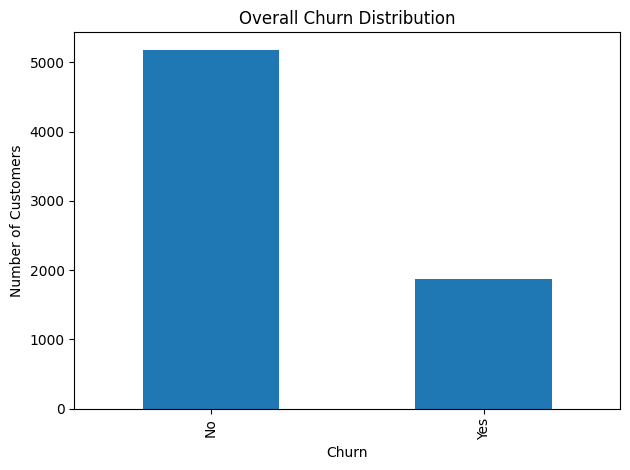

In [27]:
plt.figure()
df['Churn'].value_counts().plot(kind='bar')
plt.title("Overall Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.tight_layout()

plt.savefig(os.path.join(folder_name, "1_overall_churn.png"))
plt.show()
plt.close()

### contract vs churn

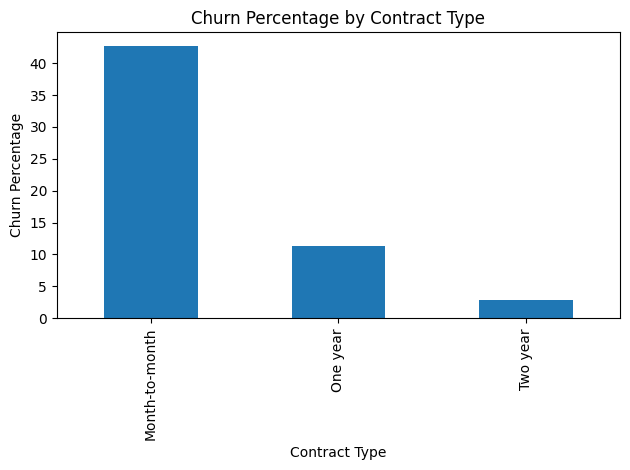

In [28]:
plt.figure()
contract_churn['Yes'].plot(kind='bar')
plt.title("Churn Percentage by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Percentage")
plt.tight_layout()

plt.savefig(os.path.join(folder_name, "2_contract_churn.png"))
plt.show()
plt.close()

### Tenure Group vs Churn

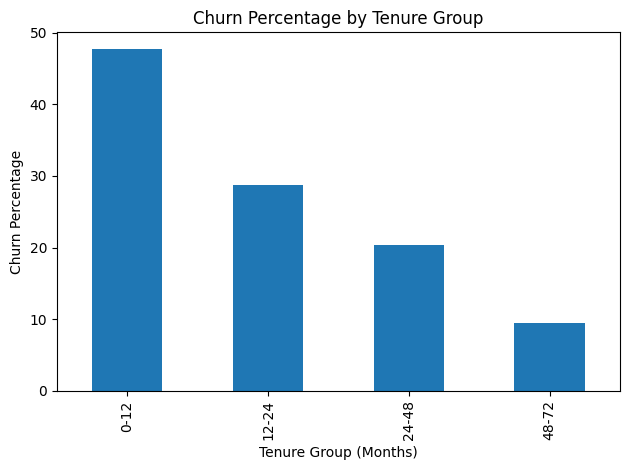

In [29]:
plt.figure()
tenure_churn['Yes'].plot(kind='bar')
plt.title("Churn Percentage by Tenure Group")
plt.xlabel("Tenure Group (Months)")
plt.ylabel("Churn Percentage")
plt.tight_layout()

plt.savefig(os.path.join(folder_name, "3_tenure_churn.png"))
plt.show()
plt.close()

### TechSupport vs Churn

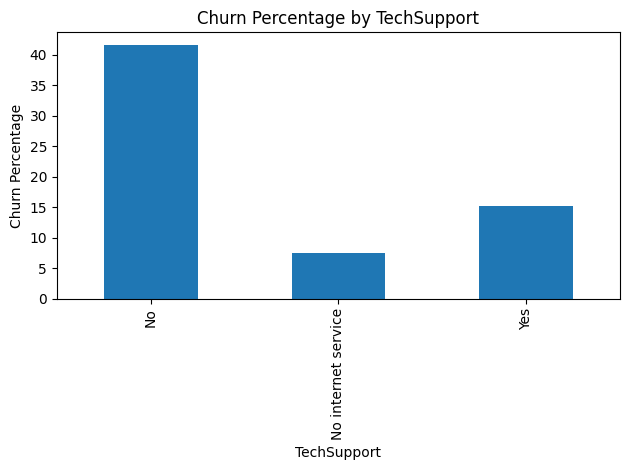

In [30]:
plt.figure()
techsupport_churn['Yes'].plot(kind='bar')
plt.title("Churn Percentage by TechSupport")
plt.xlabel("TechSupport")
plt.ylabel("Churn Percentage")
plt.tight_layout()

plt.savefig(os.path.join(folder_name, "4_techsupport_churn.png"))
plt.show()
plt.close()